##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 15.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 46.6 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import tensorflow as tf
import keras
import keras_cv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step

Predictions for Image 1: /content/drive/MyDrive/Colab Notebooks/chair.jpeg


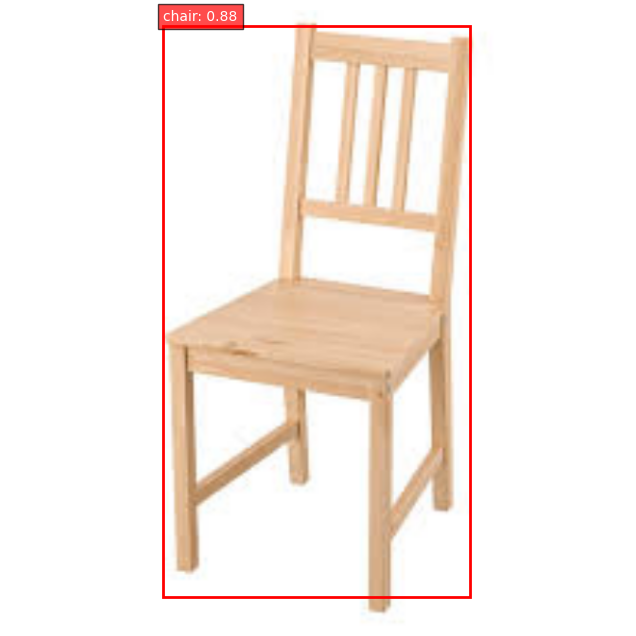


Predictions for Image 2: /content/drive/MyDrive/Colab Notebooks/car.jpeg


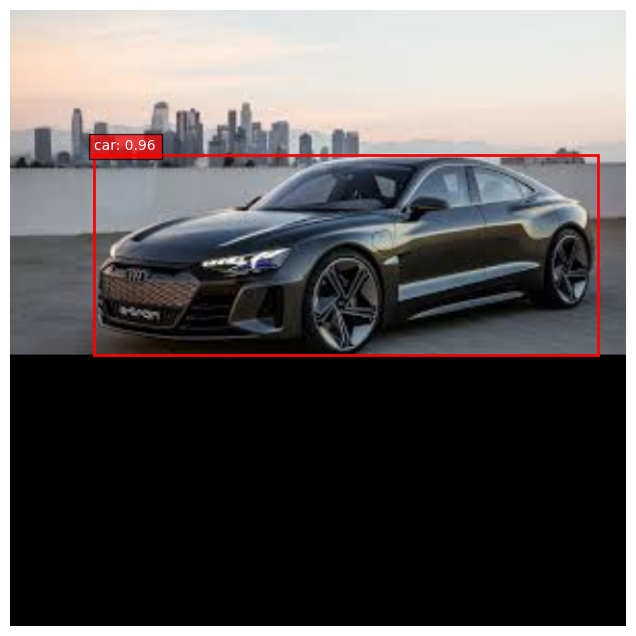


Predictions for Image 3: /content/drive/MyDrive/Colab Notebooks/horse.jpeg


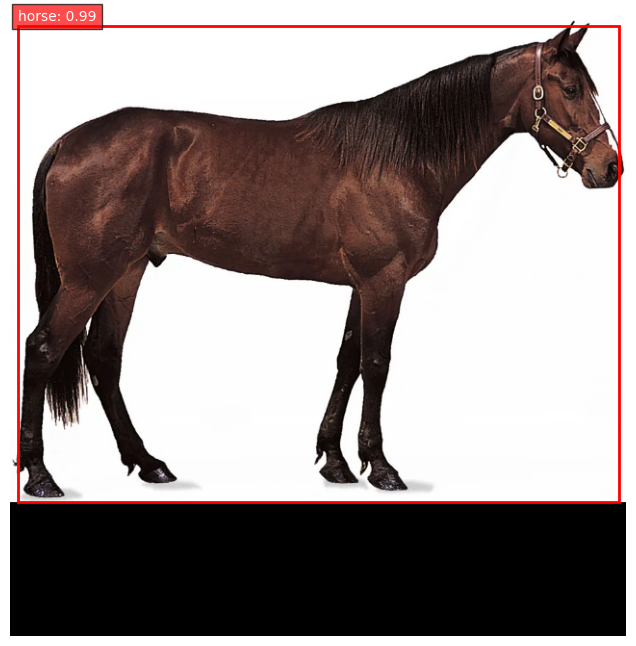


Predictions for Image 4: /content/drive/MyDrive/Colab Notebooks/sheep.jpeg


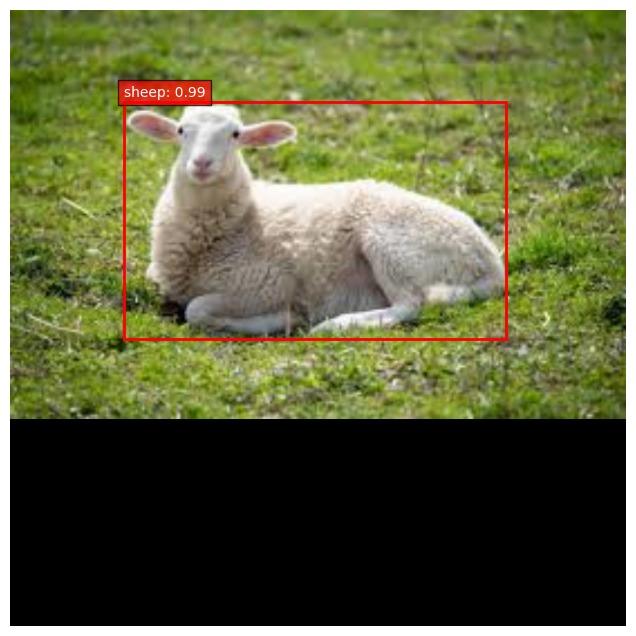


Predictions for Image 5: /content/drive/MyDrive/Colab Notebooks/cow.jpeg


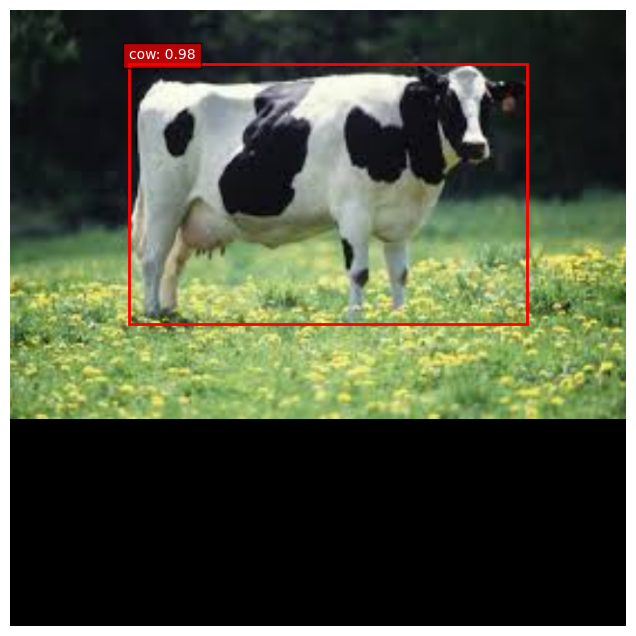

Image 1: /content/drive/MyDrive/Colab Notebooks/chair.jpeg
Detected: chair        | Confidence: 0.877 | Box: [158.94853   15.744736 318.3321   593.4607  ]
Image 2: /content/drive/MyDrive/Colab Notebooks/car.jpeg
Detected: car          | Confidence: 0.960 | Box: [ 87.1239  150.02275 523.34296 208.1764 ]
Image 3: /content/drive/MyDrive/Colab Notebooks/horse.jpeg
Detected: horse        | Confidence: 0.985 | Box: [  7.4745483   5.4071045 624.9804    495.03     ]
Image 4: /content/drive/MyDrive/Colab Notebooks/sheep.jpeg
Detected: sheep        | Confidence: 0.994 | Box: [117.74864  94.61418 397.12732 246.76622]
Image 5: /content/drive/MyDrive/Colab Notebooks/cow.jpeg
Detected: cow          | Confidence: 0.985 | Box: [122.80437   55.767326 413.7046   269.65543 ]


In [8]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import tensorflow as tf
import keras
import keras_cv

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

image_paths = [
    "/content/drive/MyDrive/Colab Notebooks/chair.jpeg",
    "/content/drive/MyDrive/Colab Notebooks/car.jpeg",
    "/content/drive/MyDrive/Colab Notebooks/horse.jpeg",
    "/content/drive/MyDrive/Colab Notebooks/sheep.jpeg",
    "/content/drive/MyDrive/Colab Notebooks/cow.jpeg"
]

def load_images_as_numpy(image_paths):
    images = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        img_np = np.array(img).astype("float32")
        images.append(img_np)
    return images

def prepare_batch(images_list, resizing_layer):
    resized_images = []
    for img in images_list:
        img_tensor = tf.convert_to_tensor(img)
        img_resized = resizing_layer(img_tensor)
        resized_images.append(img_resized)
    batch = tf.stack(resized_images, axis=0)
    return batch

def visualize_detections(image, boxes, classes, confidences, class_names, score_threshold=0.3):
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image.astype("uint8"))
    ax.axis("off")

    for box, cls_id, score in zip(boxes, classes, confidences):
        if score < score_threshold:
            continue

        x, y, w, h = box
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        cls_id = int(cls_id)
        label = f"{class_names[cls_id]}: {score:.2f}" if 0 <= cls_id < len(class_names) else f"class {cls_id}: {score:.2f}"
        ax.text(x, y - 5, label, color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.7))

    plt.show()

def print_detection_summary(predictions, class_names, image_paths, score_threshold=0.3):
    for i, path in enumerate(image_paths):
        print("=" * 60)
        print(f"Image {i+1}: {path}")

        boxes = predictions["boxes"][i]
        classes = predictions["classes"][i]
        confidences = predictions["confidence"][i]

        found_any = False

        for box, cls_id, score in zip(boxes, classes, confidences):
            if score < score_threshold:
                continue

            found_any = True
            cls_id = int(cls_id)
            class_name = class_names[cls_id] if 0 <= cls_id < len(class_names) else f"class {cls_id}"

            print(f"Detected: {class_name:12s} | Confidence: {score:.3f} | Box: {box}")

        if not found_any:
            print("No detections above threshold.")

images_list = load_images_as_numpy(image_paths)
image_batch = prepare_batch(images_list, inference_resizing)

predictions = model.predict(image_batch)

resized_images_np = image_batch.numpy()

for i in range(len(resized_images_np)):
    print(f"\nPredictions for Image {i+1}: {image_paths[i]}")

    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    confidences = predictions["confidence"][i]

    visualize_detections(
        resized_images_np[i],
        boxes,
        classes,
        confidences,
        VOC_CLASSES,
        score_threshold=0.3
    )

print_detection_summary(predictions, VOC_CLASSES, image_paths, score_threshold=0.3)

6. Record for each image:

    - Which objects were detected correctly: 
      all images were detected correctly 
    - The confidence scores of the detections:
      Listed in the previous box 
    - Any missed or incorrectly labeled objects:
      None